In [47]:
import numpy as np
import pandas as pd
import os
import datetime
import joblib
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    balanced_accuracy_score, roc_auc_score
)

from xgboost import XGBClassifier

from modAL.models import ActiveLearner
from modAL.uncertainty import margin_sampling

In [48]:
# -------------------------
# Reproducibility
# -------------------------
RANDOM_SEEDS = np.arange(20)
NUM_RUNS = len(RANDOM_SEEDS)

# -------------------------
# Active Learning settings
# -------------------------
SEED_POS = 3
SEED_TOTAL = 20
BUDGET = 70
AGG_INTERVAL = 5

# -------------------------
# Strategies
# -------------------------
strategies = ["random", "margin"]

# -------------------------
# Output
# -------------------------
OUTPUT_DIR = "../results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [49]:
XGB_PARAMS = dict(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss")

In [50]:
df = pd.read_csv("../data/final_data.csv")

TARGET = "P_HABITABLE"

X_all_df = df.drop(columns=[TARGET]).reset_index(drop=True)
y_all = df[TARGET].values
X_all_unscaled = X_all_df.values

global_idx_all = np.arange(len(X_all_unscaled))

X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X_all_unscaled, y_all, global_idx_all,
    test_size=0.20,
    stratify=y_all,
    random_state=42
)

print("Train/val size:", X_trainval.shape, "Test size:", X_test.shape)

Train/val size: (4224, 15) Test size: (1057, 15)


In [51]:
def create_seed_pool(X, y, idx, SEED_POS, SEED_TOTAL, random_state):
    rng = np.random.RandomState(random_state)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    seed_pos = rng.choice(pos_idx, SEED_POS, replace=False)
    seed_neg = rng.choice(neg_idx, SEED_TOTAL - SEED_POS, replace=False)

    seed_local = np.concatenate([seed_pos, seed_neg])
    pool_local = np.setdiff1d(np.arange(len(y)), seed_local)

    return (
        X[seed_local], y[seed_local], idx[seed_local],
        X[pool_local], y[pool_local], idx[pool_local]
    )

In [52]:
def evaluate_clf(clf, X_test, y_test):
    probs = clf.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    return dict(
        recall=recall_score(y_test, preds, pos_label=1),
        precision=precision_score(y_test, preds, pos_label=1, zero_division=0),
        f1=f1_score(y_test, preds, pos_label=1, zero_division=0),
        bal_acc=balanced_accuracy_score(y_test, preds),
        auc=roc_auc_score(y_test, probs)
    )

In [53]:
results = {s: [] for s in strategies}
selection_logs = {s: [] for s in strategies}

In [54]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning
)

In [55]:
import sklearn
print(sklearn.__version__)

1.8.0


In [56]:
total_iterations = NUM_RUNS * len(strategies) * BUDGET

with tqdm(total=total_iterations, desc="Active Learning", dynamic_ncols=True) as pbar:

    for run_i, run_seed in enumerate(RANDOM_SEEDS):

        # ---- Seed/pool split ----
        X_seed, y_seed, seed_global, X_pool, y_pool, pool_global = create_seed_pool(
            X_trainval, y_trainval, idx_trainval,
            SEED_POS, SEED_TOTAL, run_seed
        )

        scaler = RobustScaler()
        X_seed_s = scaler.fit_transform(X_seed)
        X_pool_s = scaler.transform(X_pool)
        X_test_s = scaler.transform(X_test)

        for strat in strategies:

            pbar.set_postfix(run=f"{run_i+1}/{NUM_RUNS}", strategy=strat)

            # ---- Per-strategy RNG ----
            rng = np.random.default_rng(run_seed)

            # ---- Reset seed/pool per strategy ----
            X_seed_s_strat = X_seed_s.copy()
            y_seed_strat = y_seed.copy()

            X_pool_s_strat = X_pool_s.copy()
            y_pool_strat = y_pool.copy()
            pool_global_strat = pool_global.copy()

            # ---- Initialize learner ----
            if strat == "random":
                clf = XGBClassifier(**XGB_PARAMS, random_state=run_seed)
                clf.fit(X_seed_s_strat, y_seed_strat)
                learner = None

            else:
                learner = ActiveLearner(
                    estimator=XGBClassifier(**XGB_PARAMS, random_state=run_seed),
                    query_strategy=margin_sampling,
                    X_training=X_seed_s_strat,
                    y_training=y_seed_strat
                )
                clf = learner.estimator

            # ---- History ----
            history = {k: [] for k in ["n_labeled","recall","precision","f1","bal_acc","auc"]}
            selected_seq = []

            m = evaluate_clf(clf, X_test_s, y_test)
            history["n_labeled"].append(len(y_seed_strat))
            for k in m: history[k].append(m[k])

            # ---- AL loop ----
            for _ in range(BUDGET):

                if strat == "random":
                    idx = rng.integers(0, X_pool_s_strat.shape[0])
                else:
                    idx, _ = learner.query(X_pool_s_strat)
                    idx = int(idx.item())

                selected_seq.append(pool_global_strat[idx])

                if learner:
                    learner.teach(
                        X_pool_s_strat[idx].reshape(1,-1),
                        np.array([y_pool_strat[idx]])
                    )
                else:
                    clf.fit(
                        np.vstack([X_seed_s_strat, X_pool_s_strat[idx]]),
                        np.hstack([y_seed_strat, y_pool_strat[idx]])
                    )

                # update pools
                X_seed_s_strat = np.vstack([X_seed_s_strat, X_pool_s_strat[idx]])
                y_seed_strat = np.hstack([y_seed_strat, y_pool_strat[idx]])
                X_pool_s_strat = np.delete(X_pool_s_strat, idx, axis=0)
                y_pool_strat = np.delete(y_pool_strat, idx)
                pool_global_strat = np.delete(pool_global_strat, idx)

                m = evaluate_clf(clf, X_test_s, y_test)
                history["n_labeled"].append(len(y_seed_strat))
                for k in m: history[k].append(m[k])

                pbar.update(1)

            results[strat].append(history)
            selection_logs[strat].append(selected_seq)

            joblib.dump(
                {"clf": clf, "scaler": scaler},
                os.path.join(OUTPUT_DIR, f"{strat}_run{run_i}_final.joblib")
            )

Active Learning: 100%|██████████| 2800/2800 [02:55<00:00, 15.98it/s, run=20/20, strategy=margin]


In [57]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

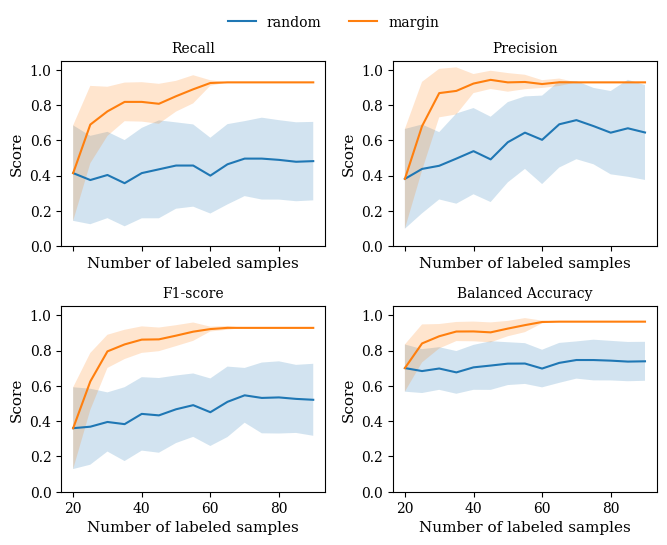

Final mean recalls: {'random': np.float64(0.4821428571428571), 'margin': np.float64(0.9285714285714285)}


In [58]:
# Aggregation & plotting
metrics = ["recall", "precision", "f1", "bal_acc"]
agg = AGG_INTERVAL

def aggregate_history_by_interval(history, agg):
    """
    history is a dict with keys 'n_labeled' and metric lists (len = BUDGET+1).
    Return arrays aggregated every agg added instances; keep the first snapshot (seed) and then every agg steps.
    """
    npoints = len(history["n_labeled"])  # BUDGET+1
    indices = list(range(0, npoints, agg))
    if indices[-1] != npoints-1:
        indices.append(npoints-1)
    out = {"n_labeled": [history["n_labeled"][i] for i in indices]}
    for m in metrics:
        out[m] = [history[m][i] for i in indices]
    return out, indices

# Build aggregated arrays across runs
agg_results = {s: {m: [] for m in ["n_labeled"] + metrics} for s in strategies}

for strat in strategies:
    for run_hist in results[strat]:
        agg_hist, idxs = aggregate_history_by_interval(run_hist, agg)
        agg_results[strat]["n_labeled"].append(agg_hist["n_labeled"])
        for m in metrics:
            agg_results[strat][m].append(agg_hist[m])

# Convert to numpy arrays (runs x time)
time_points = len(agg_results[strategies[0]]["n_labeled"][0])
xvals = agg_results[strategies[0]]["n_labeled"][0]

metric_name_map = {
    "recall": "Recall",
    "precision": "Precision",
    "f1": "F1-score",
    "bal_acc": "Balanced Accuracy"
}

# ---- Figure ----
fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.6), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, metrics):

    for strat in strategies:
        arr = np.array(agg_results[strat][m])  # (runs, time_points)
        mean_curve = np.nanmean(arr, axis=0)
        std_curve = np.nanstd(arr, axis=0)

        ax.plot(xvals, mean_curve, label=strat)
        ax.fill_between(
            xvals,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.2
        )

    ax.set_title(metric_name_map[m])
    ax.set_xlabel("Number of labeled samples")
    ax.set_ylabel("Score")
    ax.set_ylim(0.0, 1.05)

    if ax.get_legend() is not None:
        ax.legend().remove()

# ---- Shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(strategies),
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('performance.pdf')
plt.show();

# ---- Paired Wilcoxon on recall at final time point ----
# Collect final recall arrays per run for each strategy
final_recalls = {s: np.array([r["recall"][-1] for r in results[s]]) for s in strategies}
print("Final mean recalls:", {s: final_recalls[s].mean() for s in strategies})

In [59]:
# Final reporting & saving aggregated CSVs
# 1) Save selection logs per strategy
for strat in strategies:
    df_sel = pd.DataFrame(selection_logs[strat])
    df_sel.to_csv(os.path.join(OUTPUT_DIR, f"{strat}_selection_sequences.csv"), index=False)

# 2) Save aggregated mean & std per timepoint for each metric & strategy
for strat in strategies:
    # compute mean/std arrays at aggregated time points
    df_rows = []
    for run_hist in results[strat]:
        agg_hist, _ = aggregate_history_by_interval(run_hist, AGG_INTERVAL)
        df_rows.append(pd.DataFrame(agg_hist))
    df_all = pd.concat(df_rows, keys=range(len(df_rows)), names=["run","row"]).reset_index(level=0).rename(columns={"level_0":"run"})
    df_all.to_csv(os.path.join(OUTPUT_DIR, f"{strat}_aggregated_runs.csv"), index=False)

# 3) Save final model artifacts already saved during runs; summarize
print("Saved selection logs and aggregated CSVs to", OUTPUT_DIR)

Saved selection logs and aggregated CSVs to ../results


In [60]:
def extract_phase_metrics(history, seed_size,
                          early_max_queries=50,
                          early_window=10,
                          late_window=20):

    n_labeled = np.array(history["n_labeled"])
    n_queries = n_labeled - seed_size

    # Early phase: windowed near boundary
    early_mask = (n_queries > early_max_queries - early_window) & \
                 (n_queries <= early_max_queries)

    # Late phase: windowed at end
    late_mask = (n_queries >= n_queries.max() - late_window)

    return {
        "early_recall": np.mean(np.array(history["recall"])[early_mask]),
        "late_precision": np.mean(np.array(history["precision"])[late_mask]),
        "late_f1": np.mean(np.array(history["f1"])[late_mask]),
        "late_bal_acc": np.mean(np.array(history["bal_acc"])[late_mask])
    }

In [61]:
seed_size = history["n_labeled"][0]

phase_summary = {}

for strat in strategies:
    metrics = [extract_phase_metrics(h, seed_size) for h in results[strat]]
    phase_summary[strat] = {
        k: np.mean([m[k] for m in metrics])
        for k in metrics[0].keys()
    }

pd.DataFrame(phase_summary)

,random,margin
early_recall,0.455714,0.927500
late_precision,0.668573,0.928571
late_f1,0.528813,0.928571
late_bal_acc,0.740499,0.963806


## Paper Revision 1

In [62]:
plot_metrics = ["recall", "precision", "f1", "bal_acc"]

baseline_metrics = {
    "recall": 0.9285714285714286,
    "precision": 0.9285714285714286,
    "f1": 0.9285714285714286,
    "bal_acc": 0.9638063279002876
}

threshold_metrics = {
    m: 0.95 * baseline_metrics[m] for m in plot_metrics
}

In [63]:
def samples_to_threshold(x, y, threshold):
    for xi, yi in zip(x, y):
        if yi >= threshold:
            return xi
    return None

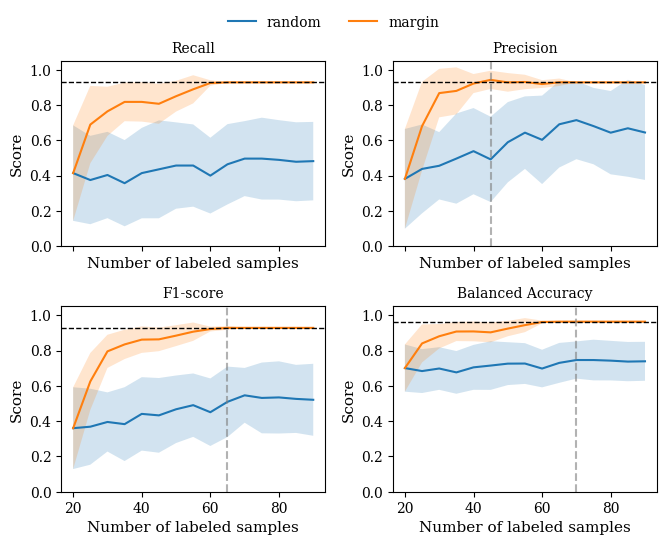

In [65]:
# from matplotlib.lines import Line2D

# ---- Figure ----
fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.6), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, plot_metrics):
    threshold = threshold_metrics[m]
    baseline = baseline_metrics[m]

    crossing_points = {}  # store where each strategy reaches threshold

    for strat in strategies:
        arr = np.array(agg_results[strat][m])  # (runs, time_points)
        mean_curve = np.nanmean(arr, axis=0)
        std_curve = np.nanstd(arr, axis=0)

        ax.plot(xvals, mean_curve, label=strat)
        ax.fill_between(
            xvals,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.2
        )

        # Find threshold crossing
        n_cross = samples_to_threshold(xvals, mean_curve, baseline)
        crossing_points[strat] = n_cross

    # Horizontal line: baseline
    ax.axhline(
        y=baseline,
        linestyle='--',
        color='black',
        linewidth=1
    )

    # # Horizontal line: threshold
    # ax.axhline(
    #     y=threshold,
    #     linestyle=':',
    #     color='gray',
    #     linewidth=1
    # )

    # Vertical lines: threshold crossing
    for strat, n_cross in crossing_points.items():
        if n_cross is not None:
            # color = next(
            #     line.get_color()
            #     for line in ax.get_lines()
            #     if line.get_label() == strat
            # )

            ax.axvline(
                x=n_cross,
                linestyle='--',
                color='gray',#color,
                alpha=0.6
            )
    
    ax.set_title(metric_name_map[m])
    ax.set_xlabel("Number of labeled samples")
    ax.set_ylabel("Score")
    ax.set_ylim(0.0, 1.05)

    if ax.get_legend() is not None:
        ax.legend().remove()

# ---- Shared legend ----
handles, labels = axes[0].get_legend_handles_labels()

# extra_lines = [
#     Line2D([0], [0], color='black', linestyle='--', label='Full XGBoost'),
#     Line2D([0], [0], color='gray', linestyle=':', label='95% Threshold')
# ]

fig.legend(
    handles,# + extra_lines,
    labels,# + [line.get_label() for line in extra_lines],
    loc="upper center",
    ncol=len(strategies),
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('performance_threshold.pdf')
plt.show();